In [8]:
import rasterio
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import tifffile as tiff

def load_sar_tiff(path):
    def _read(p):
        path_str = p.item()

        with rasterio.open(path_str) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        # Fixed-range normalization (dB)
        vv = np.clip(vv, -35.0, 5.0)
        vh = np.clip(vh, -40.0, 0.0)

        vv = (vv + 35.0) / 40.0
        vh = (vh + 40.0) / 40.0

        img = np.stack([vv, vh], axis=-1)

        # Resize 2048 → 512
        img = tf.image.resize(img, (512, 512), method="bilinear").numpy()

        return img.astype(np.float32)

    img = tf.numpy_function(_read, [path], tf.float32)
    img.set_shape([512, 512, 2])
    return img

In [9]:
def load_sar_mask(path):
    mask = tiff.imread(path)

    if mask.ndim > 2:
        mask = mask[..., 0]

    mask = (mask > 0).astype(np.float32)
    mask = cv2.resize(mask, (512, 512))
    return mask[..., None]   # (512,512,1)

In [10]:
img = load_sar_tiff("/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Images/Oil/00000.tif")
mask = load_sar_mask("/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Mask/Oil/00000_segmentation.tif")

In [11]:
import numpy as np
from skimage.filters import threshold_otsu

def otsu_on_vv_vh_ratio(img):
    if hasattr(img, "numpy"):
        img = img.numpy()

    vv = img[..., 0]
    vh = img[..., 1]

    ratio = vv / (vh + 1e-6)

    thresh = threshold_otsu(ratio)

    mask = ratio < thresh

    return mask.astype(np.uint8)

In [12]:
import numpy as np
from skimage.filters import threshold_otsu

def otsu_on_vv(img):
    if hasattr(img, "numpy"):
        img = img.numpy()

    vh = img[..., 1]

    thresh = threshold_otsu(vh)
    mask = vh < thresh

    return mask.astype(np.uint8)

In [13]:
def otsu_on_mean_intensity(img):
    intensity = np.mean(img, axis=-1)
    thresh = threshold_otsu(intensity)
    mask = intensity < thresh
    return mask.astype(np.uint8)


In [14]:
different = otsu_on_vv_vh_ratio(img)
vh = otsu_on_vv(img)
combo = otsu_on_mean_intensity(img)

In [15]:
def oil_area_pixels(mask):
    return int(np.sum(mask))

In [16]:
diff_area = oil_area_pixels(different)
vh_area = oil_area_pixels(vh)
combo_area = oil_area_pixels(combo)
og_area = oil_area_pixels(mask)

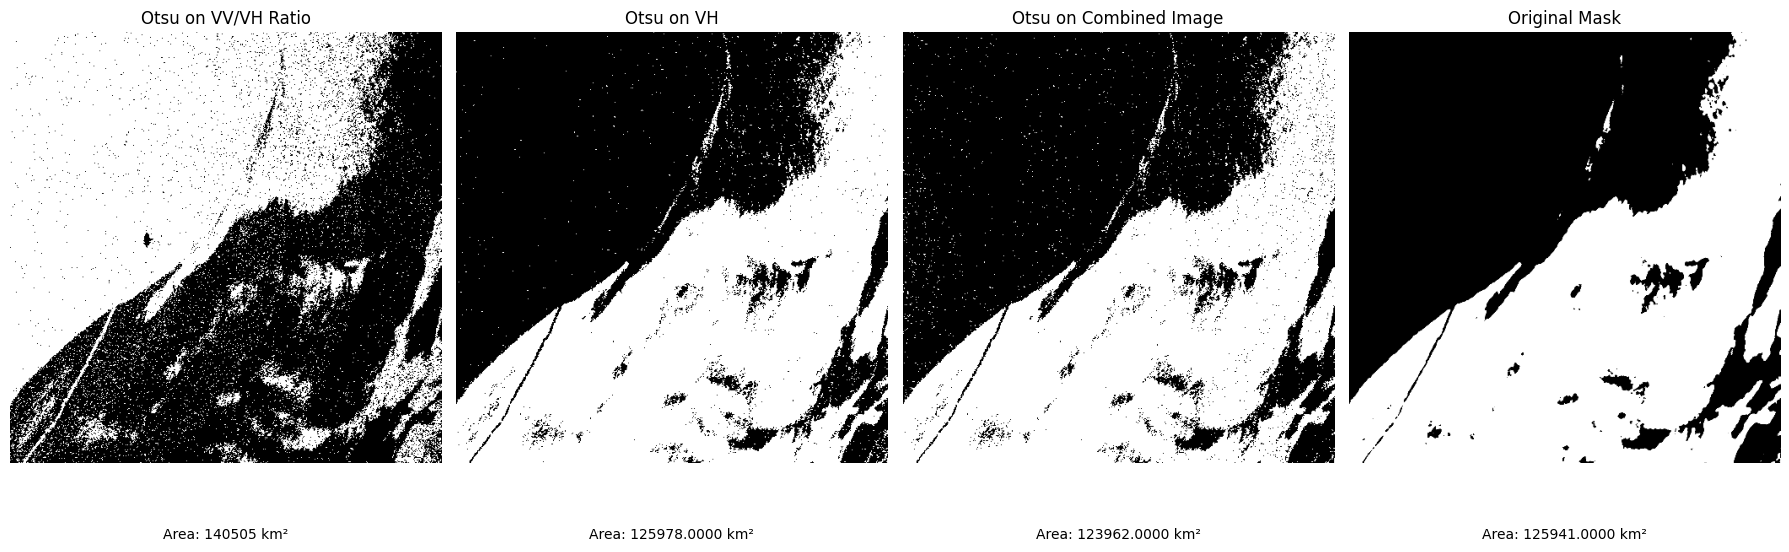

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Otsu on VV/VH Ratio
axes[0].imshow(different, cmap="gray")
axes[0].set_title("Otsu on VV/VH Ratio")
axes[0].text(
    0.5, -0.15,
    f"Area: {diff_area} km²",
    transform=axes[0].transAxes,
    ha="center", va="top", fontsize=10
)
axes[0].axis("off")

# Otsu on VH
axes[1].imshow(vh, cmap="gray")
axes[1].set_title("Otsu on VH")
axes[1].text(
    0.5, -0.15,
    f"Area: {vh_area:.4f} km²",
    transform=axes[1].transAxes,
    ha="center", va="top", fontsize=10
)
axes[1].axis("off")

# otsu on combined
axes[2].imshow(combo, cmap="gray")
axes[2].set_title("Otsu on Combined Image")
axes[2].text(
    0.5, -0.15,
    f"Area: {combo_area:.4f} km²",
    transform=axes[2].transAxes,
    ha="center", va="top", fontsize=10
)
axes[2].axis("off")

# Ground Truth Mask
axes[3].imshow(mask, cmap="gray")
axes[3].set_title("Original Mask")
axes[3].text(
    0.5, -0.15,
    f"Area: {og_area:.4f} km²",
    transform=axes[3].transAxes,
    ha="center", va="top", fontsize=10
)
axes[3].axis("off")

plt.tight_layout()
plt.show()


# Finding best approach

In [18]:
import os
import numpy as np
import rasterio
from skimage.filters import threshold_otsu


In [19]:
def otsu_vv_vh(img):
    vv, vh = img[..., 0], img[..., 1]
    ratio = vv / (vh + 1e-6)
    ratio = np.nan_to_num(ratio)
    return (ratio < threshold_otsu(ratio)).astype(np.uint8)

def otsu_vh(img):
    vh = img[..., 1]
    return (vh < threshold_otsu(vh)).astype(np.uint8)

def otsu_combined(img):
    intensity = img.mean(axis=-1)
    return (intensity < threshold_otsu(intensity)).astype(np.uint8)


In [20]:
def load_sar_np(path):
    with rasterio.open(path) as src:
        vv = src.read(1).astype(np.float32)
        vh = src.read(2).astype(np.float32)
    return np.stack([vv, vh], axis=-1)

def load_mask_np(path):
    with rasterio.open(path) as src:
        mask = src.read(1)
    return (mask > 0).astype(np.uint8)


In [21]:
def pixel_area_km2(src):
    res_x, res_y = src.res
    meters_per_degree = 111_320
    return (res_x * meters_per_degree *
            res_y * meters_per_degree) / 1e6

def area_from_mask(mask, tiff_path):
    with rasterio.open(tiff_path) as src:
        px_area = pixel_area_km2(src)
    return np.sum(mask) * px_area


In [22]:
def evaluate_otsu_methods(img_dir, mask_dir):
    errors = {
        "vv_vh": [],
        "vh": [],
        "combined": []
    }

    for fname in os.listdir(img_dir):
        if not fname.endswith(".tif"):
            continue

        img_path = os.path.join(img_dir, fname)
        mask_path = os.path.join(
            mask_dir, fname.replace(".tif", "_segmentation.tif")
        )

        if not os.path.exists(mask_path):
            continue

        img = load_sar_np(img_path)
        gt_mask = load_mask_np(mask_path)

        gt_area = area_from_mask(gt_mask, img_path)

        pred_vv_vh = otsu_vv_vh(img)
        pred_vh = otsu_vh(img)
        pred_comb = otsu_combined(img)

        area_vv_vh = area_from_mask(pred_vv_vh, img_path)
        area_vh = area_from_mask(pred_vh, img_path)
        area_comb = area_from_mask(pred_comb, img_path)

        errors["vv_vh"].append(abs(area_vv_vh - gt_area))
        errors["vh"].append(abs(area_vh - gt_area))
        errors["combined"].append(abs(area_comb - gt_area))

    return {k: np.mean(v) for k, v in errors.items()}

In [23]:
img_dir = "/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Images/Oil"
mask_dir = "/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Mask/Oil"

mean_errors = evaluate_otsu_methods(img_dir, mask_dir)

for k, v in mean_errors.items():
    print(f"{k}: Mean Area Error = {v:.4f} km²")

best_method = min(mean_errors, key=mean_errors.get)
print("\nBest Otsu approach:", best_method)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


vv_vh: Mean Area Error = 146.0156 km²
vh: Mean Area Error = 107.0233 km²
combined: Mean Area Error = 123.4841 km²

Best Otsu approach: vh
